In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix)

In [14]:
df = pd.read_csv("iris.csv")
print(df.head())

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


In [15]:
X = df.iloc[:, :-1].values
y = LabelEncoder().fit_transform(df['species'])

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [18]:
activations = ['logistic', 'tanh', 'relu']
optimizers = ['adam', 'sgd']

In [19]:
results = {}

for act in activations:
    for opt in optimizers:
        print(f"\nTraining MLP (activation={act}, optimizer={opt})...")
        mlp = MLPClassifier(
            hidden_layer_sizes=(5,),       # one hidden layer with 5 neurons
            activation=act,
            solver=opt,
            max_iter=400,
            learning_rate_init=0.01,
            random_state=42
        )
        mlp.fit(X_train, y_train)
        y_pred = mlp.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        results[(act, opt)] = {
            'model': mlp,
            'accuracy': acc,
            'loss_curve': mlp.loss_curve_,
            'predictions': y_pred
        }


Training MLP (activation=logistic, optimizer=adam)...


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (400) reached and the optimization hasn't converged yet.
  warnings.warn(



Training MLP (activation=logistic, optimizer=sgd)...


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (400) reached and the optimization hasn't converged yet.
  warnings.warn(



Training MLP (activation=tanh, optimizer=adam)...

Training MLP (activation=tanh, optimizer=sgd)...


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (400) reached and the optimization hasn't converged yet.
  warnings.warn(



Training MLP (activation=relu, optimizer=adam)...

Training MLP (activation=relu, optimizer=sgd)...


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (400) reached and the optimization hasn't converged yet.
  warnings.warn(


In [20]:
print("\n📊 Model Performance Summary:")
for (act, opt), res in results.items():
    print(f"Activation: {act}, Optimizer: {opt}, Accuracy: {res['accuracy']:.4f}")


📊 Model Performance Summary:
Activation: logistic, Optimizer: adam, Accuracy: 1.0000
Activation: logistic, Optimizer: sgd, Accuracy: 0.9333
Activation: tanh, Optimizer: adam, Accuracy: 1.0000
Activation: tanh, Optimizer: sgd, Accuracy: 1.0000
Activation: relu, Optimizer: adam, Accuracy: 1.0000
Activation: relu, Optimizer: sgd, Accuracy: 1.0000


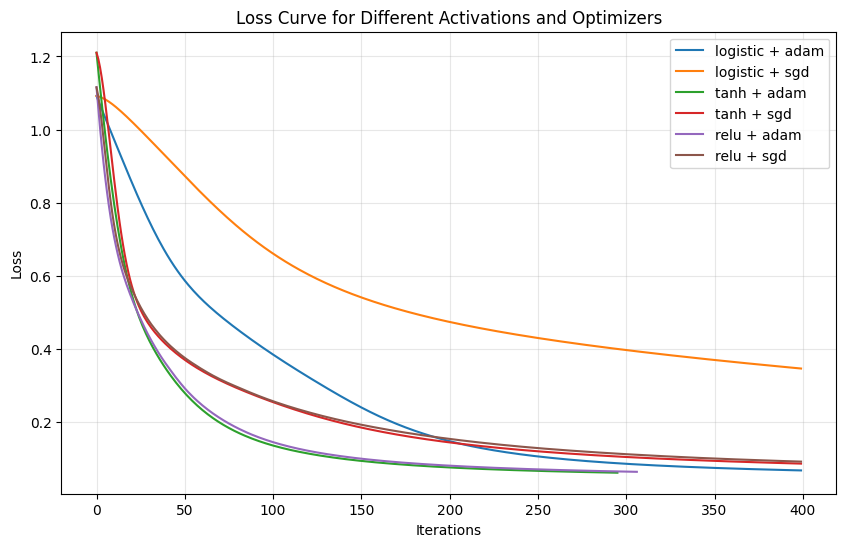

In [21]:
plt.figure(figsize=(10, 6))
for (act, opt), res in results.items():
    plt.plot(res['loss_curve'], label=f"{act} + {opt}")
plt.title("Loss Curve for Different Activations and Optimizers")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [22]:
best_key = max(results, key=lambda k: results[k]['accuracy'])
best_act, best_opt = best_key
best_model = results[best_key]['model']
y_pred_best = results[best_key]['predictions']

print(f"\n🏆 Best Model: Activation = {best_act}, Optimizer = {best_opt}")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_best))


🏆 Best Model: Activation = logistic, Optimizer = adam

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



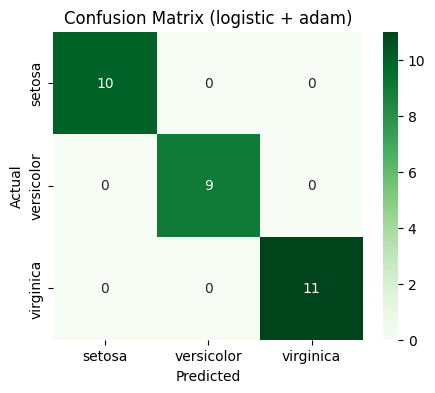

In [23]:
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=df['species'].unique(), yticklabels=df['species'].unique())
plt.title(f"Confusion Matrix ({best_act} + {best_opt})")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

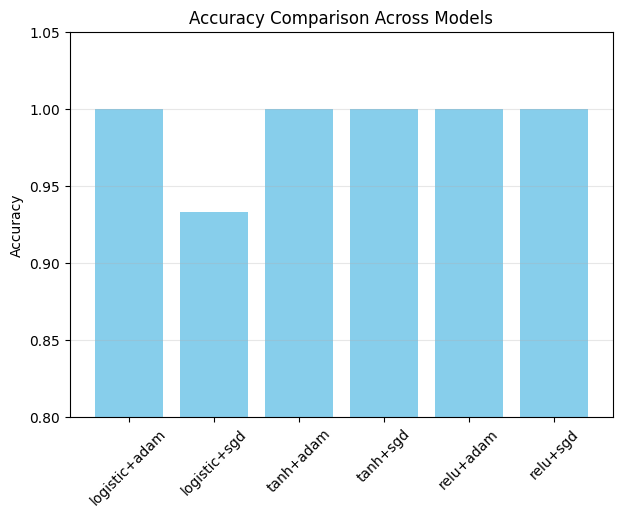

In [24]:
plt.figure(figsize=(7, 5))
acc_data = {f"{a}+{o}": r['accuracy'] for (a, o), r in results.items()}
plt.bar(acc_data.keys(), acc_data.values(), color='skyblue')
plt.title("Accuracy Comparison Across Models")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.ylim(0.8, 1.05)
plt.grid(axis='y', alpha=0.3)
plt.show()